# 붓꽃 데이터 분석

## 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

## 붓꽃(아이리스) 데이터 불러오기

In [2]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
# 기초통계량

iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# 품종

iris['species']

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: str

In [9]:
# 품목별 데이터 개수

iris['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [11]:
# count 이름의 데이터프레임

count = pd.DataFrame(iris['species'].value_counts())

In [12]:
count

,count
species,
setosa,50
versicolor,50
virginica,50


### 결측치 확인

In [13]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

### 중복데이터 확인

In [15]:
iris.duplicated().sum()

np.int64(1)

In [ ]:
index = iris.duplicated()
index

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 149, dtype: bool

In [ ]:
iris.loc[index]

# boolean -> True인 행만 선택

# 같은 결과
# iris.loc[iris.duplicated(), :]

,sepal_length,sepal_width,petal_length,petal_width,species
142,5.8,2.7,5.1,1.9,virginica


In [ ]:
result = (iris['sepal_length'] == 5.8) & (iris['petal_width'] == 1.9)
iris.loc[result]

# 조건 -> True인 행만 선택

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


### 중복데이터 삭제 : drop_duplicates()

In [20]:
iris = iris.drop_duplicates()

In [21]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [22]:
iris.loc[result]

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica


## 데이터 그룹핑

In [24]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006000,3.428000,1.462000,0.246000
versicolor,5.936000,2.770000,4.260000,1.326000
virginica,6.604082,2.979592,5.561224,2.028571


# 붓꽃 데이터 시각화

In [26]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 꽃받침의 길이 시각화 - 막대그래프

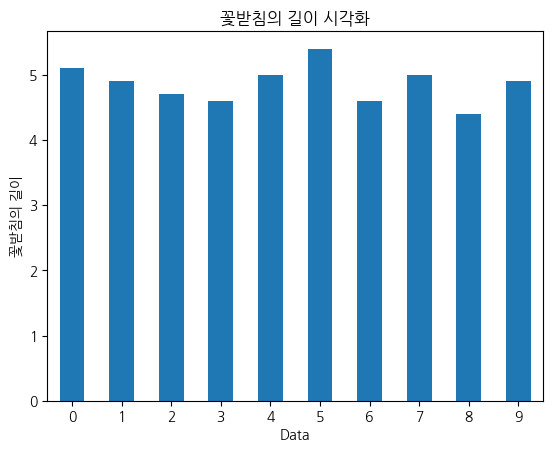

In [ ]:
iris.sepal_length[:10].plot(kind='bar', rot=0) # 10개의 데이터, 막대그래프, 회전 0도
plt.title('꽃받침의 길이 시각화')
plt.xlabel('Data')
plt.ylabel('꽃받침의 길이')
plt.show()

## 붓꽃의 품종별 그룹화 - 평균 -> 새로운 데이터프레임으로 저장 -> 차트 생성

In [60]:
df2 = iris.groupby('species').mean()
df2

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006000,3.428000,1.462000,0.246000
versicolor,5.936000,2.770000,4.260000,1.326000
virginica,6.604082,2.979592,5.561224,2.028571


### 품종별 꽃받침 길이 그래프

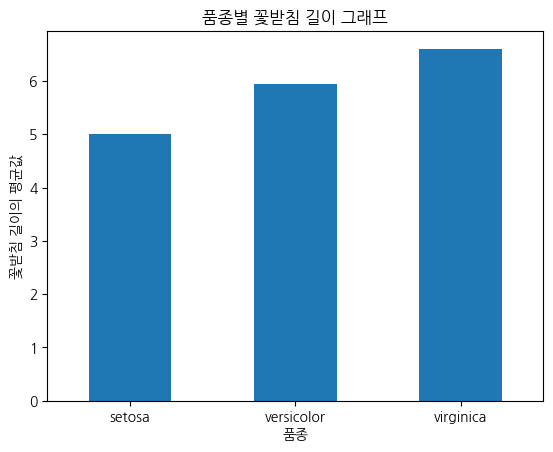

In [61]:
df2.sepal_length[:].plot(kind='bar', rot=0)
plt.title('품종별 꽃받침 길이 그래프')
plt.xlabel('품종')
plt.ylabel('꽃받침 길이의 평균값')
plt.show()

## 히스토그램(빈도수 그래프)

<function matplotlib.pyplot.show(close=None, block=None)>

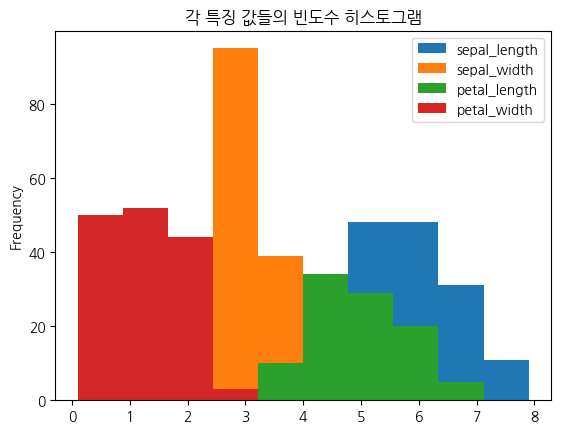

In [32]:
iris.plot(kind='hist')
plt.title('각 특징 값들의 빈도수 히스토그램')

plt.show

## 상자 그래프

- 이상치 발견

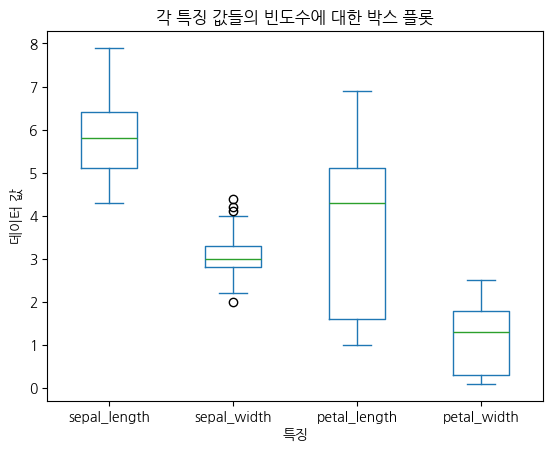

In [33]:
iris.plot(kind='box')
plt.title('각 특징 값들의 빈도수에 대한 박스 플롯')
plt.xlabel('특징')
plt.ylabel('데이터 값')
plt.show()

## 산점도 그래프(산포 그래프)

- 두 변수 간의 관계

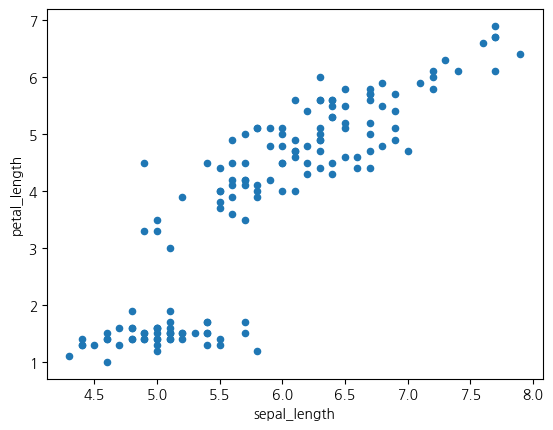

In [34]:
iris.plot(x='sepal_length', y='petal_length', kind='scatter')
plt.show()

연습문제 1

In [65]:
# 1-1
# 'species' 기준로 최대값, 최소값 구하기

x = iris.groupby('species').max()
y = iris.groupby('species').min()

In [66]:
print(x)
print(y)

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa               5.8          4.4           1.9          0.6
versicolor           7.0          3.4           5.1          1.8
virginica            7.9          3.8           6.9          2.5
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa               4.3          2.3           1.0          0.1
versicolor           4.9          2.0           3.0          1.0
virginica            4.9          2.2           4.5          1.4


In [40]:
# 1-2
# 컬럼명 변경 후 상위 5개 데이터 출력

iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [ ]:
iris2 = iris.rename(columns={
    'sepal_length':'SL',
    'sepal_width':'SW',
    'petal_length':'PL',
    'petal_width':'PW',
    'species':'SP'
})
iris2.head()

# 같은 결과
# iris2 = iris.copy()
# iris2.columns = ['SL', 'SW', 'PL', 'PW', 'SP']
# iris2.head()

,SL,SW,PL,PW,SP
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


연습문제 2

In [45]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# 2-1
# total_bill, tip에 대해 오름차순 정렬 후 상위 10개 출력

tips.sort_values(by=['total_bill', 'tip']).head(10)

,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
92,5.75,1.00,Female,Yes,Fri,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
172,7.25,5.15,Male,Yes,Sun,Dinner,2
149,7.51,2.00,Male,No,Thur,Lunch,2
195,7.56,1.44,Male,No,Thur,Lunch,2
218,7.74,1.44,Male,Yes,Sat,Dinner,2
145,8.35,1.50,Female,No,Thur,Lunch,2
135,8.51,1.25,Female,No,Thur,Lunch,2
126,8.52,1.48,Male,No,Thur,Lunch,2


In [ ]:
# 2-2
# size 기준 내림차순, tip 기준 오름차순 정렬 후 상위 10개 출력

tips.sort_values(by=['size', 'tip'], ascending=[False, True]).head(10)

,total_bill,tip,sex,smoker,day,time,size
125,29.80,4.20,Female,No,Thur,Lunch,6
143,27.05,5.00,Female,No,Thur,Lunch,6
156,48.17,5.00,Male,No,Sun,Dinner,6
141,34.30,6.70,Male,No,Thur,Lunch,6
187,30.46,2.00,Male,Yes,Sun,Dinner,5
216,28.15,3.00,Male,Yes,Sat,Dinner,5
142,41.19,5.00,Male,No,Thur,Lunch,5
185,20.69,5.00,Male,No,Sun,Dinner,5
155,29.85,5.14,Female,No,Sun,Dinner,5
153,24.55,2.00,Male,No,Sun,Dinner,4


연습문제 3

In [ ]:
# 3-1
# 꽃받침 너비 기준 내림차순 정렬

i = sns.load_dataset('iris')
i.sort_values(by='sepal_width', ascending=False)

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
33,5.5,4.2,1.4,0.2,setosa
32,5.2,4.1,1.5,0.1,setosa
14,5.8,4.0,1.2,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
...,...,...,...,...,...
53,5.5,2.3,4.0,1.3,versicolor
62,6.0,2.2,4.0,1.0,versicolor
68,6.2,2.2,4.5,1.5,versicolor
119,6.0,2.2,5.0,1.5,virginica


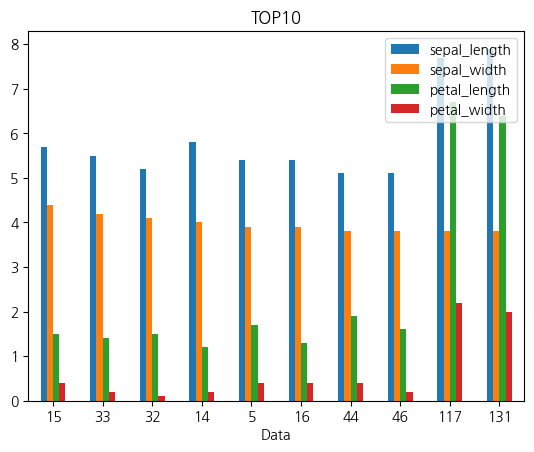

In [ ]:
# 3-2
# 3-1 결과 상위 10개 데이터 -> 막대 그래프

i2 = i.sort_values(by='sepal_width', ascending=False)
i2 = i2.head(10)

i2.plot(kind='bar', rot=0)
plt.title('TOP10')
plt.xlabel('Data')
plt.legend(loc='upper right')
plt.show()

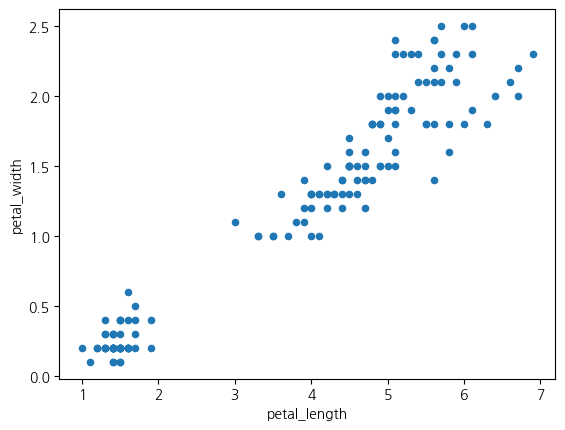

In [64]:
# 3-3
# 꽃잎 길이, 꽃잎 너비 -> 산점도 그래프

i.plot(x='petal_length', y='petal_width', kind='scatter')
plt.show()

연습문제 4

In [68]:
titanic = pd.read_csv('train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 4-1
# 성별에 따른 생존율

pd.DataFrame(titanic.groupby('Sex')['Survived'].mean())

,Survived
Sex,
female,0.742038
male,0.188908


In [99]:
# 4-2
# 함께 승선한 부모와 자식 수(Parch)에 따른 생존율

titanic[['Parch', 'Survived']].groupby('Parch', as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [117]:
# 4-3
# 객실 등급, 성별 별로 Survived, Age 평균 출력

titanic.groupby(['Pclass', 'Sex'])[['Survived', 'Age']].mean()

Survived        Age
Pclass Sex                        
1      female  0.968085  34.611765
       male    0.368852  41.281386
2      female  0.921053  28.722973
       male    0.157407  30.740707
3      female  0.500000  21.750000
       male    0.135447  26.507589

In [121]:
# 4-4
# 항구별 생존자 -> 시각화

titanic2 = titanic[['Embarked', 'Survived']]
titanic2

,Embarked,Survived
0,S,0
1,C,1
2,S,1
3,S,1
4,S,0
...,...,...
886,S,0
887,S,1
888,S,0
889,C,1


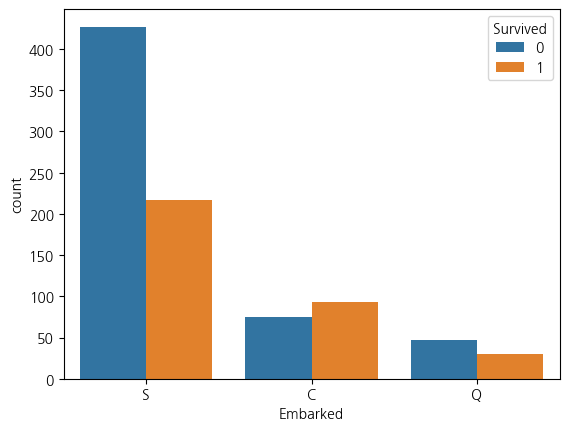

In [122]:
# seaborn 사용 -> 생존자 건수 -> countplot()
sns.countplot(data=titanic2, x='Embarked', hue='Survived')
plt.show()